### Basic Analysis and Visualisations

In [316]:
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [317]:
FILE_PATH = "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grids.csv"
df = pd.read_csv(FILE_PATH)
df.shape

(2000, 14)

In [318]:
df.columns

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty'],
      dtype='object')

In [319]:
new_df = df.copy(deep=True)

In [320]:
def safe_divide(a, b):
    return np.where(b <= 2, 0, a / b)

### Feature Derivation

In [321]:
new_df["usable_area_percent"] = 100.0 - (new_df["empty"] + new_df["water_percent"])
new_df["kirana_potential_index"] = np.log2(
    1 + new_df["yellow_building_count"]
) * safe_divide(new_df["yellow_building_density"], new_df["total_building_density"])
new_df["local_road_proportion"] = safe_divide(
    new_df["local_road_density"], new_df["total_road_density"]
)

##### CSV Features:

In [322]:
#   Using the latitude and longitude to derive "dist_to_nearest_hub" feature
#   We are only doing it for Delhi
#   To include curvature of Earth, we use "haversine distance"

hub_threshold = new_df["total_building_density"].quantile(0.95)
hubs_df = new_df[new_df["total_building_density"] >= hub_threshold][
    ["latitude", "longitude"]
].dropna()

hubs_rad = np.radians(hubs_df[["latitude", "longitude"]].values)
all_coords_rad = np.radians(new_df[["latitude", "longitude"]].values)

tree = BallTree(hubs_rad, metric="haversine")
distances_rad, indices = tree.query(all_coords_rad, k=1)

new_df["dist_to_nearest_hub"] = distances_rad * 6371.0

In [324]:
new_df.columns

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty',
       'usable_area_percent', 'kirana_potential_index',
       'local_road_proportion', 'dist_to_nearest_hub'],
      dtype='object')

In [325]:
cols_to_drop = [
    "grid_id",
    "latitude",
    "longitude",
    "waterbody",
    "building_count",
    "water_percent",
    "empty",
]
X = new_df.drop(columns=cols_to_drop)
X.columns

Index(['yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'usable_area_percent', 'kirana_potential_index',
       'local_road_proportion', 'dist_to_nearest_hub'],
      dtype='object')

In [337]:
from matplotlib import pyplot as plt
import seaborn as sns

In [339]:
from grid_determination_bizom.constant import COLS_TO_KEEP

new_df_new = new_df[COLS_TO_KEEP]

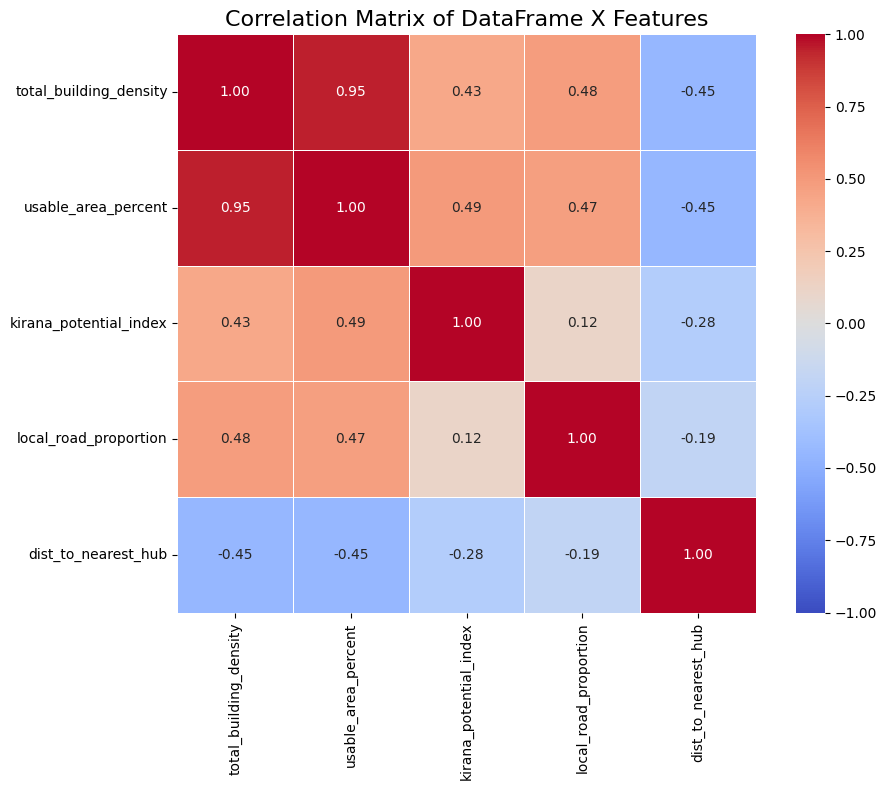

In [ ]:
corr_matrix = new_df_new.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of DataFrame X Features", fontsize=16)
plt.tight_layout()

In [327]:
X_scaled = StandardScaler().fit_transform(new_df.drop(cols_to_drop, axis=1))
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
labels = gmm.fit_predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

new_df["labels"] = labels
for i in range(probs.shape[1]):
    new_df[f"prob_cluster_{i}"] = probs[:, i]

new_df.sort_values(by="empty", inplace=True, ascending=False)

In [328]:
new_df.head(60)

,grid_id,latitude,longitude,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,...,water_percent,empty,usable_area_percent,kirana_potential_index,local_road_proportion,dist_to_nearest_hub,labels,prob_cluster_0,prob_cluster_1,prob_cluster_2
0,12666,28.492956,76.942579,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,9.833573,2,0.0,2.234629e-28,1.0
334,56548,28.823535,77.126817,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,2.996625,2,0.0,8.466425e-28,1.0
272,7347,28.451634,77.259878,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,6.470609,2,0.0,5.192656e-28,1.0
99,5513,28.439058,76.915967,0,1,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,16.248128,2,0.0,1.130614e-29,1.0
278,53901,28.803772,77.067452,0,1,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,4.288063,2,0.0,6.928119e-28,1.0
689,59355,28.845094,77.026510,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,5.383361,2,0.0,6.309115e-28,1.0
286,20047,28.548652,76.948720,0,1,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,5.629874,2,0.0,5.491002e-28,1.0
93,60142,28.850484,77.175947,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,7.669859,2,0.0,4.008093e-28,1.0
92,1830,28.410312,77.171853,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,11.969458,2,0.0,1.082848e-28,1.0
761,61022,28.857671,77.028557,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,100.0,0.0,0.0,0.0,5.368979,2,0.0,6.323776e-28,1.0


In [329]:
new_df["labels"].value_counts()

labels
0    699
1    691
2    610
Name: count, dtype: int64

In [330]:
new_df.sort_values(by="grid_id", inplace=True)
new_df.to_csv(
    "/Users/saranyapal/Developer/grid-determination-bizom/outputs/results_gmm_improved.csv"
)

In [331]:
#   Labels:
#   0 => Medium Potential
#   1 => Low Potential
#   2 => High Potential


In [332]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

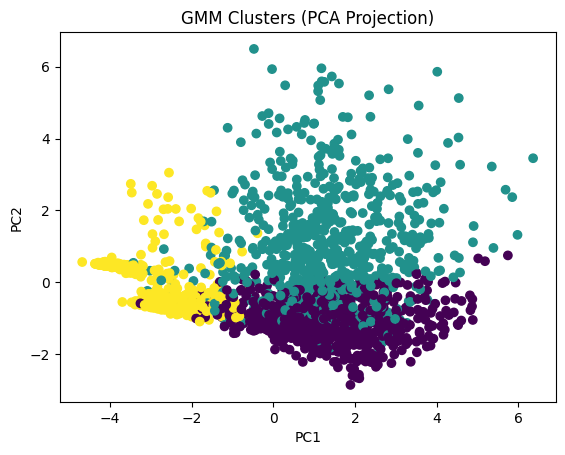

In [333]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters (PCA Projection)")
plt.show()

In [334]:
new_df.groupby("labels")["usable_area_percent"].mean().sort_values()

labels
2     5.933869
1    51.510767
0    55.664492
Name: usable_area_percent, dtype: float64

In [335]:
new_df.groupby("labels")["usable_area_percent"].median().sort_values()

labels
2     3.535
1    52.090
0    55.930
Name: usable_area_percent, dtype: float64

<Axes: xlabel='labels', ylabel='usable_area_percent'>

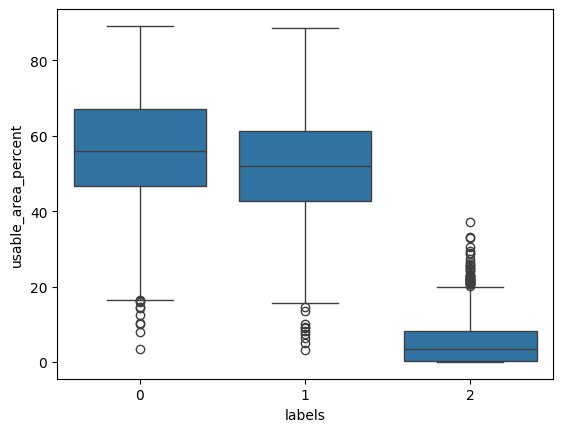

In [336]:
import seaborn as sns

sns.boxplot(x="labels", y="usable_area_percent", data=new_df)